In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd
from math import *

#Presets

We define `G` as `1.0` in order to scale data for the dataset. The mass unit is `10^30` kg (Sun's mass), and the length unit is one `AU` (astronomical unit), equivalent of `149,597,870,700 ​≈ 1.5e11` meters. Because G is `1.0`, the time is no longer measured the seconds, but one time unit becomes `≈ 7 082 478` seconds or `​≈ 82` days (from the definition of `G`).

In [155]:
G_REAL = 6.6743e-11 # gravitational constant
G = 1

MU = 1e30
AU = 149597870700 # ​≈ 1.5e11

TU = sqrt(AU**3 / (G_REAL * MU)) # ​≈ 7 082 478 seconds ≈ 82 days
TU_AU = TU / AU # used for generating bodies' velocities

print(TU)
print(TU_AU)

7082478.360008018
4.734344363905454e-05


In [156]:
dt = 0.001 # time step in time units
steps = 2000

For a more accurate approach, we use a softening constant `epsilon`. It will prevent the division by `0` in case the distances between bodies are small.
If the distances between bodies are almost zero (collision), it will cause almost infinite force and, therefore, infinite acceleration that will drift the bodies away.

In [157]:
epsilon = 0.05 # softening parameter

In [158]:
METHODS = {
    0: "Kepler 2-Body",
    1: "Semi-Implicit Euler",
    2: "Velocity Verlet",
    3: "Runge-Kutta 4"
}

N = int(input("Number of bodies: "))
print("N =", N)

if (N > 10) or (N < 2):
  raise ValueError("Number of bodies must be between 2 and 10.")

if N == 2:
  option = int(input("Method: 0 = Kepler (2-Body), 1 = Semi-Implicit Euler, 2 = Velocity Verlet, 3 = RK4: "))
else:
  option = int(input("Method: 1 = Semi-Implicit Euler, 2 = Velocity Verlet, 3 = RK4: "))

if option not in METHODS:
  raise ValueError("Invalid method")

print("Selected method:", METHODS[option])

Number of bodies: 6
N = 6
Method: 1 = Semi-Implicit Euler, 2 = Velocity Verlet, 3 = RK4: 3
Selected method: Runge-Kutta 4


#Classes & Functions

##Base Classes

For improved modularity and code organization, we define the class `Body` as the core component of the simulation framework. It serves as a base class from which we derive the subclasses `EulerBody`, `KeplerBody`, `VerletBody`, and `RK4Body`. These subclasses implement different numerical integration schemes, corresponding to the Semi-Implicit Euler, Velocity Verlet, and Runge-Kutta (RK4) methods. In addition, the `KeplerBody` class provides an analytical solution for the Kepler two-body problem.

In [159]:
class Body:
  def __init__(self, mass, position, velocity):
    self.mass = float(mass)
    self.position = np.array(position, dtype=float)
    self.velocity = np.array(velocity, dtype=float)
    self.acceleration = np.zeros(2, dtype=float)

  def __repr__(self):
    pos_str = np.array2string(self.position, formatter={'float_kind':lambda x: f"{x:.6f}"})
    vel_str = np.array2string(self.velocity, formatter={'float_kind':lambda x: f"{x:.6f}"})
    acc_str = np.array2string(self.acceleration, formatter={'float_kind':lambda x: f"{x:.6f}"})

    return (
        f"mass: {self.mass:.6f}, "
        f"pos: {pos_str}, "
        f"vel: {vel_str}, "
        f"acc: {acc_str}"
    )

##Derived Classes

In [160]:
class KeplerBody(Body):
  def __init__(self, mass, position, velocity):
    super().__init__(mass, position, velocity)
    self.mu = 0
    self.a = 0
    self.e = 0
    self.n = 0
    self.M0 = 0
    self.arg_perigee = 0

  def init_orbit(self, central_body):
    r_vec = self.position - central_body.position
    v_vec = self.velocity - central_body.velocity

    r_mag = np.linalg.norm(r_vec)
    v_mag_sq = np.dot(v_vec, v_vec)

    self.mu = central_body.mass + self.mass
    self.a = 1.0 / ((2.0 / r_mag) - (v_mag_sq / self.mu))

    rdotv = np.dot(r_vec, v_vec)

    v2_mur = v_mag_sq - self.mu / r_mag

    e_vec = (v2_mur * r_vec - rdotv * v_vec) / self.mu
    self.e = np.linalg.norm(e_vec)

    self.arg_perigee = atan2(e_vec[1], e_vec[0])
    self.n = sqrt(self.mu / (self.a ** 3))

    cos_nu = np.clip(np.dot(e_vec, r_vec) / (self.e * r_mag), -1.0, 1.0)

    nu0 = np.arccos(cos_nu)
    if rdotv < 0:
        nu0 = 2 * pi - nu0

    E0 = 2 * atan2(
        sqrt(1 - self.e**2) * sin(nu0),
        1 - self.e * cos(nu0)
    )

    self.M0 = E0 - self.e * sin(E0)

  def step_kepler(self, t, central_body):
    M = (self.M0 + self.n * t) % (2 * pi)

    E_val = M
    delta = 1

    for _ in range(50):
      f = E_val - self.e * sin(E_val) - M
      f_prime = 1 - self.e * cos(E_val)

      delta = f / f_prime
      E_val -= delta

      if abs(delta) < 1e-12: break

    x_p = self.a * (cos(E_val) - self.e)
    y_p = self.a * sqrt(1 - self.e**2) * sin(E_val)

    r_inst = self.a * (1 - self.e * cos(E_val))
    v_factor = sqrt(self.mu * self.a) / r_inst

    vx_p = -v_factor * sin(E_val)
    vy_p = v_factor * sqrt(1 - self.e**2) * cos(E_val)

    cos_ap = cos(self.arg_perigee)
    sin_ap = sin(self.arg_perigee)

    x_rel = x_p * cos_ap - y_p * sin_ap
    y_rel = x_p * sin_ap + y_p * cos_ap

    vx_rel = vx_p * cos_ap - vy_p * sin_ap
    vy_rel = vx_p * sin_ap + vy_p * cos_ap

    Mtot = self.mass + central_body.mass

    self.position = np.array([
        -(central_body.mass / Mtot) * x_rel,
        -(central_body.mass / Mtot) * y_rel
    ])

    central_body.position = np.array([
        (self.mass / Mtot) * x_rel,
        (self.mass / Mtot) * y_rel
    ])

    self.velocity = np.array([
        -(central_body.mass / Mtot) * vx_rel,
        -(central_body.mass / Mtot) * vy_rel
    ])

    central_body.velocity = np.array([
        (self.mass / Mtot) * vx_rel,
        (self.mass / Mtot) * vy_rel
    ])

In [161]:
class EulerBody(Body):
  def update_accelerations(self, others):
    accelerations = np.zeros(2, dtype=float)

    for other in others:
      if other is self: continue

      r_vec = other.position - self.position
      r_mag = np.linalg.norm(r_vec)

      accelerations += other.mass * r_vec / (r_mag**2 + epsilon**2)**1.5

    self.acceleration[:] = accelerations

  def update_velocity_positions(self, dt):
    # Semi-Implicit Euler (Euler-Cromer) Method
    self.velocity += self.acceleration * dt
    self.position += self.velocity * dt

In [162]:
class VerletBody(Body):
  def __init__(self, mass, position, velocity):
    super().__init__(mass, position, velocity)
    self.old_acceleration = np.zeros(2, dtype=float)

  def update_acceleration(self, others):
    # store old acceleration
    self.old_acceleration = self.acceleration.copy()
    acc = np.zeros(2, dtype=float)
    for other in others:
      if other is self: continue
      r_vec = other.position - self.position
      r_sq_eps = np.dot(r_vec, r_vec) + epsilon**2
      acc += other.mass * r_vec / (r_sq_eps ** 1.5)
    self.acceleration = acc

  def update_velocity(self, dt):
    self.velocity += 0.5 * (self.old_acceleration + self.acceleration) * dt

  def update_position(self, dt):
    self.position += (self.velocity * dt + 0.5 * self.acceleration * dt**2)

In [163]:
class RK4Body(Body):
  def __init__(self, mass, position, velocity):
    super().__init__(mass, position, velocity)
    # k vectors (velocity + acceleration samples)
    self.kv = [np.zeros(2) for _ in range(4)]
    self.ka = [np.zeros(2) for _ in range(4)]
    # temporary states
    self.temp_pos = np.zeros(2)
    self.temp_vel = np.zeros(2)

  def get_acceleration(self, others):
    acc = np.zeros(2)
    for other in others:
      if other is self: continue
      r_vec = other.temp_pos - self.temp_pos
      r2_epsilon = np.dot(r_vec, r_vec) + epsilon**2
      acc += other.mass * r_vec / (r2_epsilon ** 1.5)
    return acc

##Validation Functions

In order to check simulation's accuracy, we calculate the total energy of the system, the total linear momnetum and angular momentum. The system is stable if these metrics remain almost constant over time, with no visible drifts.

The formulas for kinetic energy, potential energy, linear momentum and angular momentum are implemented as dedicated functions. Additional functions are defined to compute the total energy, total linear and angular momentum of the system at a given time step by summing the contributions of all bodies.

In [164]:
# Kinetic Energy
def KE(m, v): return 0.5 * m * np.dot(v, v)

# Potential Energy
def PE(m1, m2, r1, r2, option):
  r_vec = r1 - r2
  r2_val = np.dot(r_vec, r_vec)

  if option == 0:
    r = np.sqrt(r2_val)
    return -m1 * m2 / r
  else:
    return -m1 * m2 / np.sqrt(r2_val + epsilon**2)

# Linear Momentum
def P(m, v): return m * np.array(v)

# Angular Momentum
def L(m, r, v): return m * (r[0] * v[1] - r[1] * v[0])

# Total Energy
def energy(bodies, option):
  ke = 0.0
  pe = 0.0

  for i, body in enumerate(bodies):
    ke += KE(body.mass, body.velocity)
    for j in range(i + 1, len(bodies)):
      pe += PE(body.mass, bodies[j].mass, body.position, bodies[j].position, option)
  return ke + pe

# Total Linear Momentum
def linear_momentum(bodies):
  current_p = np.array([0.0, 0.0])
  for body in bodies: current_p += P(body.mass, body.velocity)
  return current_p

# Total Angular Momentum
def angular_momentum(bodies):
  current_l = 0
  for body in bodies: current_l += L(body.mass, body.position, body.velocity)
  return current_l

In [165]:
def calculate_validation_step(bodies, option, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
    nom_E = abs(E0) if abs(E0) > 1e-15 else 1.0
    nom_P = np.linalg.norm(P0) if np.linalg.norm(P0) > 1e-15 else 1.0
    nom_L = abs(L0) if abs(L0) > 1e-15 else 1.0

    E_current = energy(bodies, option)
    P_current = linear_momentum(bodies)
    L_current = angular_momentum(bodies)

    err_e_abs = abs(E_current - E0)
    err_p_abs = np.linalg.norm(P_current - P0)
    err_l_abs = abs(L_current - L0)

    e.append(E_current)
    p.append(np.linalg.norm(P_current))
    l.append(L_current)

    abs_e.append(err_e_abs)
    abs_p.append(err_p_abs)
    abs_l.append(err_l_abs)

    rel_e.append((err_e_abs / nom_E) * 100)
    rel_p.append((err_p_abs / nom_P) * 100)
    rel_l.append((err_l_abs / nom_L) * 100)

##Simulation Functions

The exact solution to the two-body problem is given by Kepler's method, which reduces the system to an equivalent one-body problem by considering motion relative to the center of mass. As an analytical solution, it allows the positions of the bodies to be computed directly at any given time `t`, without the need for iterative numerical integration.

In [166]:
def run_kepler(steps, dt, bodies, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  body1 = bodies[0]
  body2 = bodies[1]

  x.clear()
  y.clear()

  x.extend([[], []])
  y.extend([[], []])

  body1.init_orbit(body2)
  current_time = 0

  for _ in range(steps):

    # UPDATE PARAMETERS
    current_time += dt
    body1.step_kepler(current_time, body2)


    # PLOT
    # Calculate validation parameters
    calculate_validation_step(bodies, 0, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)

    # Add the new positions
    x[0].append(body1.position[0])
    y[0].append(body1.position[1])

    x[1].append(body2.position[0])
    y[1].append(body2.position[1])

Euler Integration method is a first-order numerical method for solving ordinary differential equations. In our case, it is the simplest and most intuitive method. In this simulator, the Semi-Implicit Euler (Euler–Cromer) variant is used, where velocities are updated before positions, providing improved stability for N-body simulations based on Newtonian mechanics.

In [167]:
def run_euler(steps, dt, bodies, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  for _ in range(steps):

    # UPDATE PARAMETERS
    # Update accelerations
    for body in bodies:
      body.update_accelerations(bodies)

    # Update velocity and positions
    for body in bodies:
      body.update_velocity_positions(dt)


    # PLOT
    # Calculate validation parameters
    calculate_validation_step(bodies, 1, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)

    # Add the new positions
    for i, body in enumerate(bodies):
      x[i].append(body.position[0])
      y[i].append(body.position[1])

The Velocity Verlet method is a second-order numerical integrator widely used in physical simulations due to its improved accuracy and stability. It updates positions and velocities in a time-symmetric manner, providing better energy conservation over long simulations compared to simpler methods like Euler.

In [168]:
def run_verlet(steps, dt, bodies, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  for _ in range(steps):

    # UPDATE PARAMETERS
    # Update positions
    for body in bodies:
      body.update_position(dt)

    # Update accelerations
    for body in bodies:
      body.update_acceleration(bodies)

    # Update velocities
    for body in bodies:
      body.update_velocity(dt)


    # PLOT
    # Calculate validation parameters
    calculate_validation_step(bodies, 2, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)

    # Add the new positions
    for i, body in enumerate(bodies):
      x[i].append(body.position[0])
      y[i].append(body.position[1])

The Runge–Kutta 4 (RK4) method is a fourth-order numerical integrator known for its high accuracy in solving ordinary differential equations. It estimates the system's evolution by combining multiple intermediate evaluations within each time step, providing precise results at the cost of increased computational complexity.

In [169]:
def run_rk4(steps, dt, bodies, x, y, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l):
  for _ in range(steps):
    # UPDATE PARAMETERS

    # Step k1
    # Assign values to temporary variables
    for b in bodies:
        b.temp_pos = b.position.copy()

    # kv1 and ka1 are the current velocity and acceleration values
    for b in bodies:
        b.kv[0] = b.velocity.copy()
        b.ka[0] = b.get_acceleration(bodies)

    # Step k2
    # Calculate the temporary positions and velocities at half-step
    for b in bodies:
        b.temp_pos = b.position + b.kv[0] * dt * 0.5
        b.temp_vel = b.velocity + b.ka[0] * dt * 0.5

    # Recalculate the accelerations given the updated positions
    for b in bodies:
        b.kv[1] = b.temp_vel.copy()
        b.ka[1] = b.get_acceleration(bodies)

    # Step k3
    # Recalculate the temporary positions and velocities at half-step using past slope (velocity and acceleration)
    for b in bodies:
        b.temp_pos = b.position + b.kv[1] * dt * 0.5
        b.temp_vel = b.velocity + b.ka[1] * dt * 0.5

    for b in bodies:
        b.kv[2] = b.temp_vel.copy()
        b.ka[2] = b.get_acceleration(bodies)

    # Step k4
    # Calculate the "draft" of the final positions and velocities
    for b in bodies:
        b.temp_pos = b.position + b.kv[2] * dt
        b.temp_vel = b.velocity + b.ka[2] * dt

    for b in bodies:
        b.kv[3] = b.temp_vel.copy()
        b.ka[3] = b.get_acceleration(bodies)

    # Final Integration
    for b in bodies:
        b.position += (dt / 6.0) * (b.kv[0] + 2*b.kv[1] + 2*b.kv[2] + b.kv[3])
        b.velocity += (dt / 6.0) * (b.ka[0] + 2*b.ka[1] + 2*b.ka[2] + b.ka[3])

    # PLOT
    # Calculate validation parameters
    calculate_validation_step(bodies, 3, E0, P0, L0, e, p, l, abs_e, abs_p, abs_l, rel_e, rel_p, rel_l)

    # Add the new positions
    for i, body in enumerate(bodies):
      x[i].append(body.position[0])
      y[i].append(body.position[1])

In [170]:
def generate_bodies(option):
  bodies = []

  sum_vx = 0.0
  sum_vy = 0.0

  for i in range(N):
    mass = rd.uniform(0.5, 2)

    x_pos = rd.uniform(-1, 1)
    y_pos = rd.uniform(-1, 1)

    if i < N - 1:
      vx = rd.uniform(-2e4, 2e4) * TU_AU
      vy = rd.uniform(-2e4, 2e4) * TU_AU

      sum_vx += mass * vx
      sum_vy += mass * vy

    else:
      vx = -sum_vx / mass
      vy = -sum_vy / mass

    pos = np.array([x_pos, y_pos], dtype=float)
    vel = np.array([vx, vy], dtype=float)

    if option == 0: body = KeplerBody(mass, pos, vel)
    elif option == 1: body = EulerBody(mass, pos, vel)
    elif option == 2: body = VerletBody(mass, pos, vel)
    elif option == 3: body = RK4Body(mass, pos, vel)

    bodies.append(body)
    print(f"Body {i+1}: {body}")

  return bodies

#Simulation Loop

Generating the random configurations of the bodies.

In [171]:
bodies = generate_bodies(option)

Body 1: mass: 1.162067, pos: [-0.027159 0.107876], vel: [-0.810443 -0.181904], acc: [0.000000 0.000000]
Body 2: mass: 1.249135, pos: [-0.431687 -0.109000], vel: [-0.832749 0.207738], acc: [0.000000 0.000000]
Body 3: mass: 0.512697, pos: [-0.040274 -0.562158], vel: [0.156576 0.024057], acc: [0.000000 0.000000]
Body 4: mass: 0.881209, pos: [-0.699925 0.177565], vel: [-0.771682 -0.893300], acc: [0.000000 0.000000]
Body 5: mass: 1.547216, pos: [0.768005 0.151714], vel: [-0.732962 0.659884], acc: [0.000000 0.000000]
Body 6: mass: 1.465319, pos: [0.601593 -0.013806], vel: [2.535824 -0.200802], acc: [0.000000 0.000000]


Defining the arrays where we store data about trajectories coordinates (`x`, `y`) and system's invariants (`energy`, `linear`, `angular`), together with their absolute errors (`abs_energy`, `abs_linear`, `abs_angular`) and relative errors (`rel_energy`, `rel_linear`, `rel_angular`).

In [172]:
# Trajectories coordinates
x = []
y = []

# Absolute values
total_energy = []
total_linear = []
total_angular = []

# Absolute errors
abs_energy = []
abs_linear = []
abs_angular = []

# Relative errors
rel_energy = []
rel_linear = []
rel_angular = []

E0 = energy(bodies, option)
P0 = linear_momentum(bodies)
L0 = angular_momentum(bodies)

for body in bodies:
  x.append([body.position[0]])
  y.append([body.position[1]])

In [173]:
if option == 0:
  run_kepler(
      steps, dt, bodies,
      x, y, E0, P0, L0,
      total_energy, total_linear, total_angular,
      abs_energy, abs_linear, abs_angular,
      rel_energy, rel_linear, rel_angular
      )
elif option == 1:
  run_euler(
      steps, dt, bodies,
      x, y, E0, P0, L0,
      total_energy, total_linear, total_angular,
      abs_energy, abs_linear, abs_angular,
      rel_energy, rel_linear, rel_angular
      )
elif option == 2:
  run_verlet(
      steps, dt, bodies,
      x, y, E0, P0, L0,
      total_energy, total_linear, total_angular,
      abs_energy, abs_linear, abs_angular,
      rel_energy, rel_linear, rel_angular
      )
elif option == 3:
  run_rk4(
      steps, dt, bodies,
      x, y, E0, P0, L0,
      total_energy, total_linear, total_angular,
      abs_energy, abs_linear, abs_angular,
      rel_energy, rel_linear, rel_angular
      )

#Plotting

##Trajectories

The plot below shows the trajectories followed by each body in the system during the simulation.

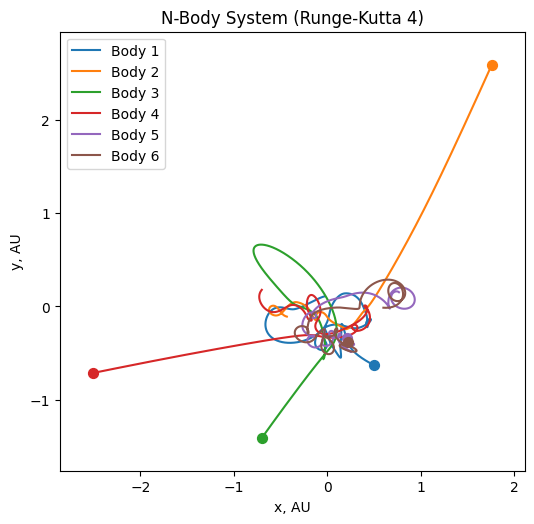

In [174]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')

all_x = [val for body_x in x for val in body_x]
all_y = [val for body_y in y for val in body_y]

margin = max(all_x) * 0.2

ax.set_xlim(min(all_x) - margin, max(all_x) + margin)
ax.set_ylim(min(all_y) - margin, max(all_y) + margin)

for i in range(len(bodies)):
    ax.plot(x[i], y[i], label=f'Body {i + 1}')
    ax.scatter(x[i][-1], y[i][-1], s=50, zorder=5)

ax.legend()
ax.set_title(f"N-Body System ({METHODS.get(option)})")
ax.set_xlabel("x, AU")
ax.set_ylabel("y, AU")

plt.savefig("3-body.pdf", bbox_inches="tight")
plt.show()

##Validation Check

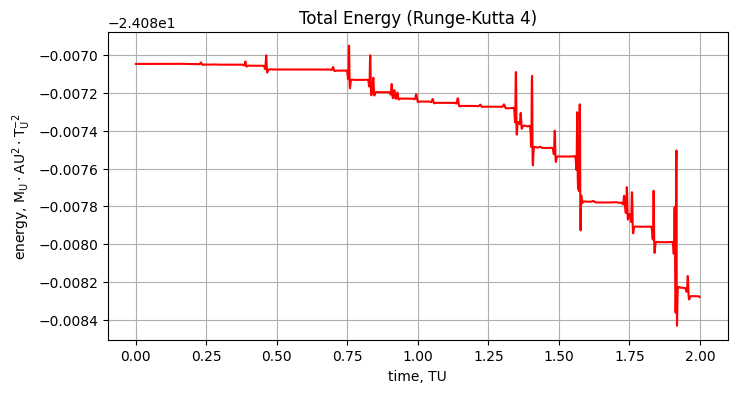

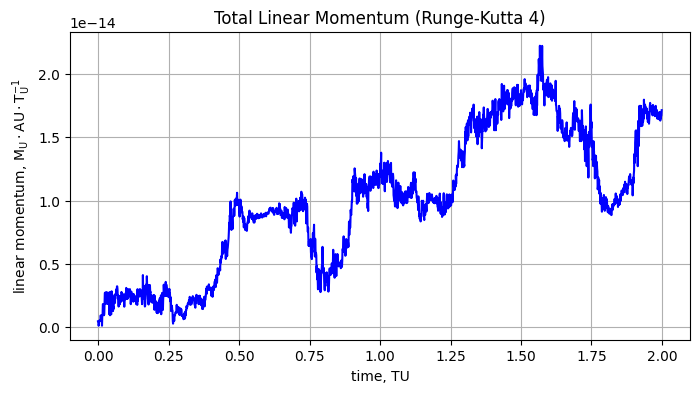

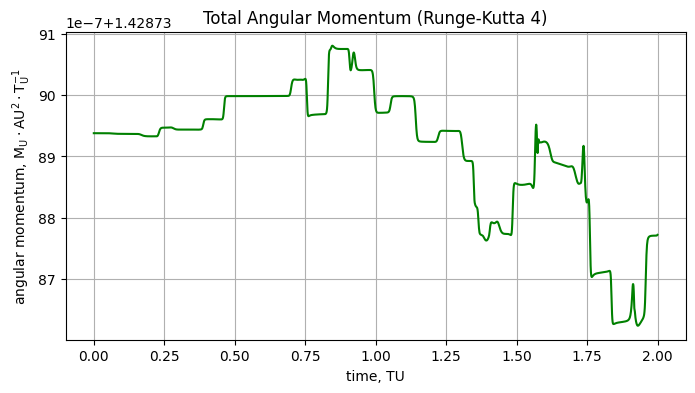

In [175]:
time_axis = [i * dt for i in range(len(total_energy))]

# Total Energy
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(time_axis, total_energy, color='red')
ax1.set_title(f"Total Energy ({METHODS.get(option)})")
ax1.set_ylabel(r"energy, $\text{M}_\text{U} \cdot \text{AU}^2 \cdot \text{T}_\text{U}^{-2}$")
ax1.set_xlabel("time, TU")
ax1.grid(True)

# Total Linear Momentum
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(time_axis, total_linear, color='blue')
ax2.set_title(f"Total Linear Momentum ({METHODS.get(option)})")
ax2.set_ylabel(r"linear momentum, $\text{M}_\text{U} \cdot \text{AU} \cdot \text{T}_\text{U}^{-1}$")
ax2.set_xlabel("time, TU")
ax2.grid(True)

# Total Angular Momentum
fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.plot(time_axis, total_angular, color='green')
ax3.set_title(f"Total Angular Momentum ({METHODS.get(option)})")
ax3.set_ylabel(r"angular momentum, $\text{M}_\text{U} \cdot \text{AU}^2 \cdot \text{T}_\text{U}^{-1}$")
ax3.set_xlabel("time, TU")
ax3.grid(True)

plt.show()

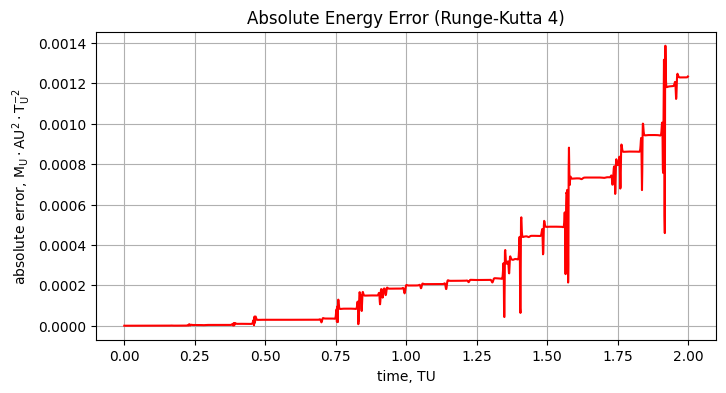

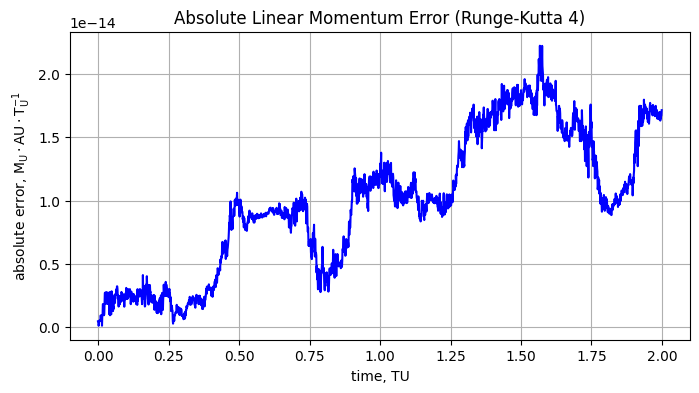

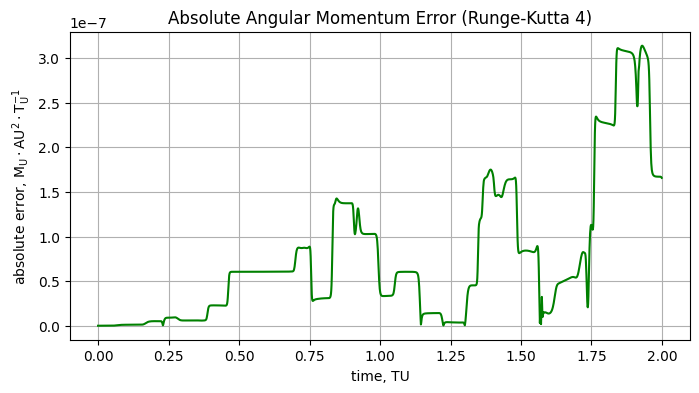

In [176]:
time_axis = [i * dt for i in range(len(abs_energy))]

# Absolute Energy Error
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(time_axis, abs_energy, color='red')
ax1.set_title(f"Absolute Energy Error ({METHODS.get(option)})")
ax1.set_ylabel(r"absolute error, $\text{M}_\text{U} \cdot \text{AU}^2 \cdot \text{T}_\text{U}^{-2}$")
ax1.set_xlabel("time, TU")
ax1.grid(True)

# Absolute Linear Momentum Error
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(time_axis, abs_linear, color='blue')
ax2.set_title(f"Absolute Linear Momentum Error ({METHODS.get(option)})")
ax2.set_ylabel(r"absolute error, $\text{M}_\text{U} \cdot \text{AU} \cdot \text{T}_\text{U}^{-1}$")
ax2.set_xlabel("time, TU")
ax2.grid(True)

# Absolute Angular Momentum Error
fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.plot(time_axis, abs_angular, color='green')
ax3.set_title(f"Absolute Angular Momentum Error ({METHODS.get(option)})")
ax3.set_ylabel(r"absolute error, $\text{M}_\text{U} \cdot \text{AU}^2 \cdot \text{T}_\text{U}^{-1}$")
ax3.set_xlabel("time, TU")
ax3.grid(True)

plt.show()

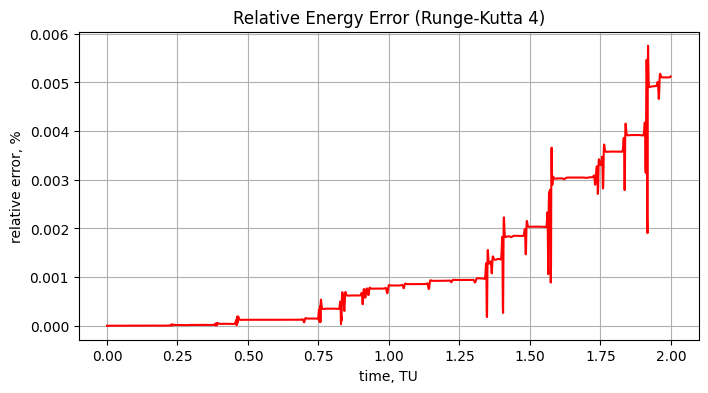

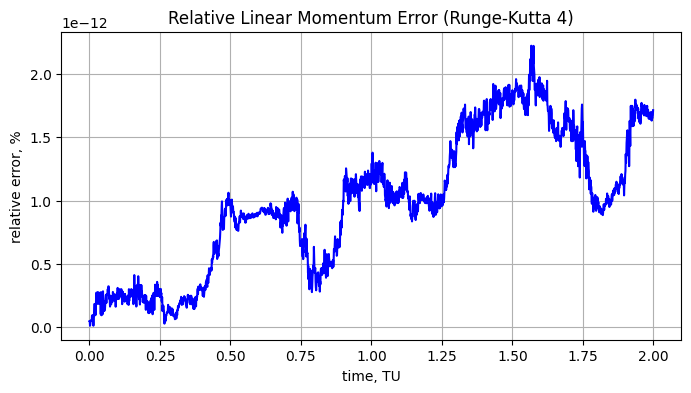

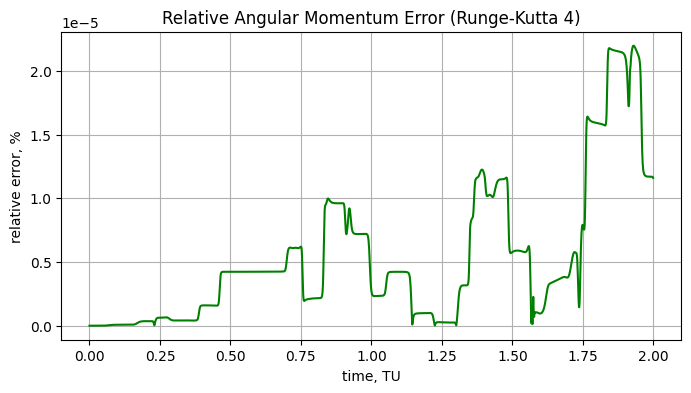

In [177]:
time_axis = [i * dt for i in range(len(rel_energy))]

# Relative Energy Error
fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(time_axis, rel_energy, color='red')
ax1.set_title(f"Relative Energy Error ({METHODS.get(option)})")
ax1.set_ylabel("relative error, %")
ax1.set_xlabel("time, TU")
ax1.grid(True)

# Relative Linear Momentum Error
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(time_axis, rel_linear, color='blue')
ax2.set_title(f"Relative Linear Momentum Error ({METHODS.get(option)})")
ax2.set_ylabel("relative error, %")
ax2.set_xlabel("time, TU")
ax2.grid(True)

# Relative Angular Momentum Error
fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.plot(time_axis, rel_angular, color='green')
ax3.set_title(f"Relative Angular Momentum Error ({METHODS.get(option)})")
ax3.set_ylabel("relative error, %")
ax3.set_xlabel("time, TU")
ax3.grid(True)

plt.show()